# آموزش و مقایسه مدل‌ها

دو مدل Random Forest و SVM 
- رو آموزش می‌دم و مقایسه می‌کنم هایپرپارامترهاشون رو تنظیم
می‌کنم و بهترین رو ذخیره می‌کنم

چون کلاس‌ها نامتوازن‌ان فقط به دقت 
- (accuracy)
-
 نگاه نمی‌کنم معیارهای 
 - precision 
 - recall 
 - F1  
 - ROC-AUC
  رو هم می‌بینم

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## خواندن داده آماده‌شده

داده پیش‌پردازش‌شده رو که نوت‌بوک قبلی ذخیره کرده بود می‌خونم

In [2]:
# دادهٔ پیش‌پردازش‌شده را از نوت‌بوک قبلی می‌خوانم
data = joblib.load('../models/preprocessed_data.pkl')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f'train: {X_train.shape[0]}, test: {X_test.shape[0]}, features: {X_train.shape[1]}')

train: 614, test: 154, features: 8


## یک تابع کمکی برای ارزیابی

یه تابع کوچیک می‌نویسم که مدل رو روی تست اجرا کنه و همه معیارها رو برگردونه تا برای
هر مدل کد رو تکرار نکنم

In [3]:
# تابع کمکی: مدل را روی تست اجرا می‌کند و معیارها را برمی‌گرداند
def evaluate(model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }

## مدل اول: Random Forest

  

مجموعه‌ای از چند درخت تصمیمه. به مقیاس‌بندی نیازی نداره ولی ضرر هم نمی‌زنه با

- `class_weight='balanced'` 
نامتوازنی رو جبران می‌کنم.

In [4]:
# آموزش Random Forest با ۱۰۰ درخت
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # جبران عدم توازن کلاس‌ها
    random_state=42,
    n_jobs=-1,                 # استفاده از همه هسته‌های پردازنده
)
rf.fit(X_train, y_train)
rf_metrics = evaluate(rf)

print('Random Forest')
for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f'  {k:10s} {rf_metrics[k]:.3f}')

Random Forest
  accuracy   0.747
  precision  0.660
  recall     0.574
  f1         0.614
  roc_auc    0.811


In [5]:
# گزارش کامل طبقه‌بندی
print(classification_report(y_test, rf.predict(X_test),
                            target_names=['No diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No diabetes       0.79      0.84      0.81       100
    Diabetes       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



## مدل دوم: SVM

با کرنل RBF. این یکی واقعاً به همون مقیاس‌بندی‌ای که قبلاً کردم نیاز داره.

In [6]:
# آموزش SVM با کرنل RBF
svm = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    probability=True,   # برای محاسبه احتمال‌ها (لازم برای ROC-AUC)
    random_state=42,
)
svm.fit(X_train, y_train)
svm_metrics = evaluate(svm)

print('SVM')
for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f'  {k:10s} {svm_metrics[k]:.3f}')

SVM
  accuracy   0.727
  precision  0.591
  recall     0.722
  f1         0.650
  roc_auc    0.814


In [7]:
print(classification_report(y_test, svm.predict(X_test),
                            target_names=['No diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No diabetes       0.83      0.73      0.78       100
    Diabetes       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



## مقایسهٔ دو مدل

حالا معیارهای دو مدل رو کنار هم می‌ذارم.

In [8]:
# جدول مقایسهٔ معیارها
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
compare = pd.DataFrame({
    'Random Forest': [rf_metrics[m] for m in metric_names],
    'SVM': [svm_metrics[m] for m in metric_names],
}, index=metric_names).round(3)
compare

,Random Forest,SVM
accuracy,0.747,0.727
precision,0.660,0.591
recall,0.574,0.722
f1,0.614,0.650
roc_auc,0.811,0.814


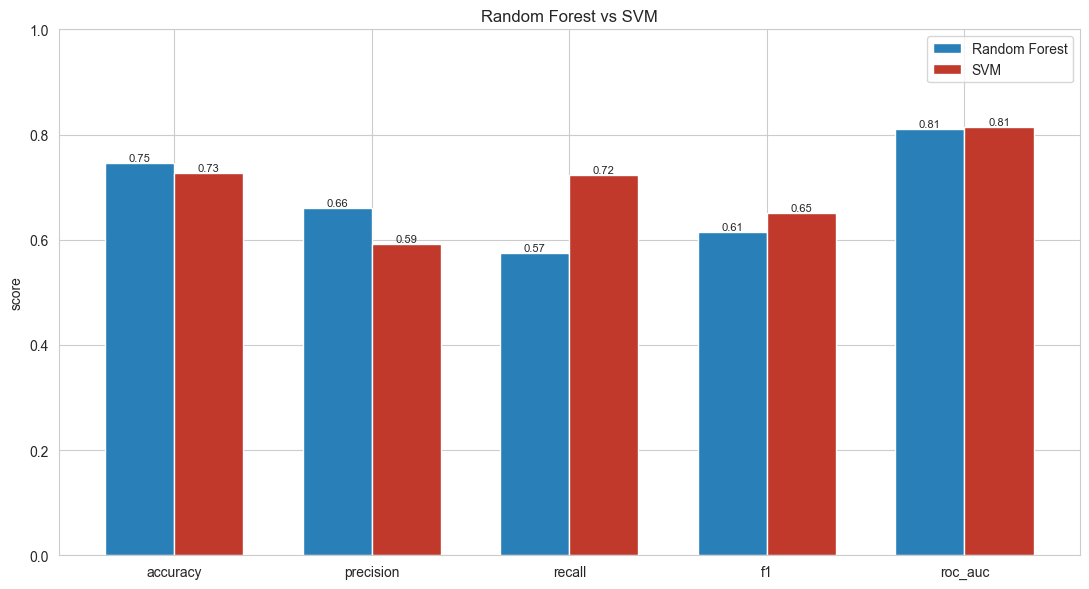

In [9]:
# نمودار میله‌ای مقایسهٔ معیارها
rf_vals = [rf_metrics[m] for m in metric_names]
svm_vals = [svm_metrics[m] for m in metric_names]
x = np.arange(len(metric_names))
w = 0.35

plt.figure(figsize=(11, 6))
b1 = plt.bar(x - w/2, rf_vals, w, label='Random Forest', color='#2980b9')
b2 = plt.bar(x + w/2, svm_vals, w, label='SVM', color='#c0392b')
plt.xticks(x, metric_names)
plt.ylim(0, 1)
plt.ylabel('score')
plt.title('Random Forest vs SVM')
plt.legend()
for bars in (b1, b2):
    for b in bars:
        plt.text(b.get_x() + b.get_width()/2, b.get_height(),
                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## ماتریس درهم‌ریختگی (Confusion Matrix)

چهار خونه داره: تشخیص درستِ سالم، تشخیص درستِ دیابتی، و دو نوع خطا. خطای مهم‌تر FN‌ه:
بیماری که اشتباهاً سالم تشخیص داده شده.

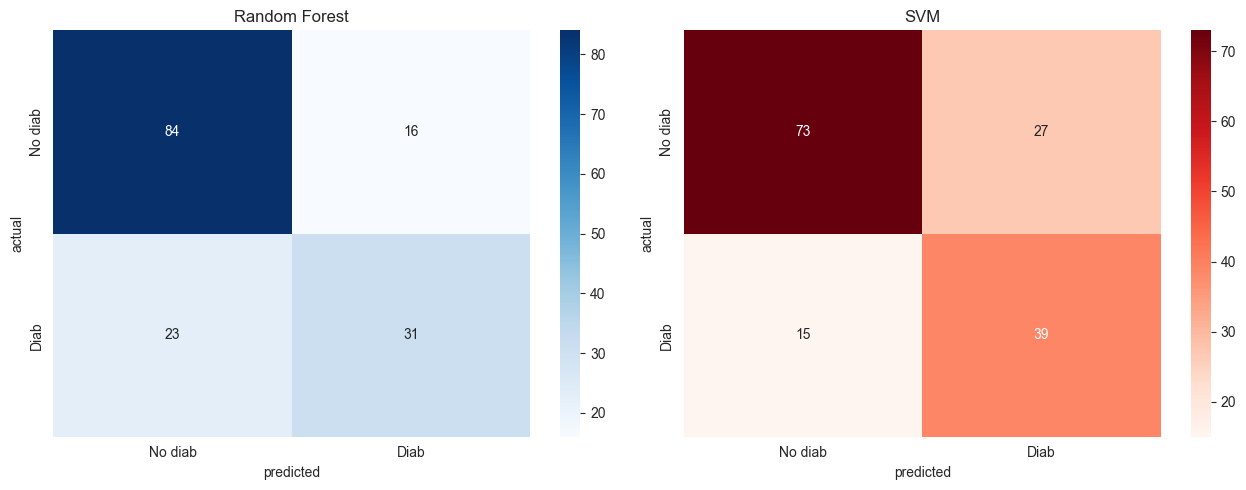

In [10]:
# ماتریس درهم‌ریختگی هر دو مدل
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(rf_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No diab', 'Diab'], yticklabels=['No diab', 'Diab'])
axes[0].set_title('Random Forest')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('actual')

sns.heatmap(svm_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No diab', 'Diab'], yticklabels=['No diab', 'Diab'])
axes[1].set_title('SVM')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('actual')
plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## منحنی ROC

هرچه منحنی به گوشهٔ بالا-چپ نزدیک‌تر و سطح زیرش (AUC) بزرگ‌تر باشه، مدل بهتره.

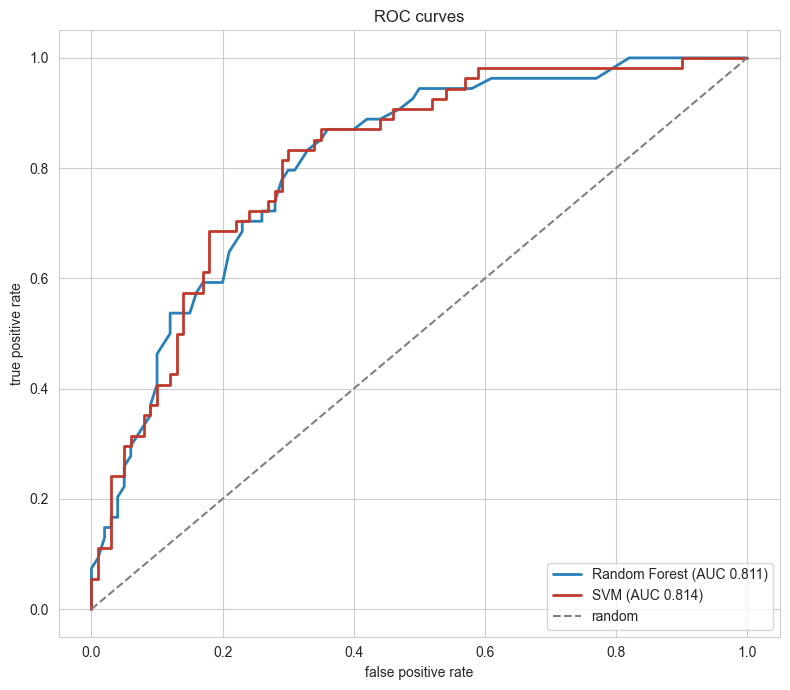

In [11]:
# منحنی ROC برای هر دو مدل
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 7))
plt.plot(rf_fpr, rf_tpr, color='#2980b9', lw=2, label=f"Random Forest (AUC {rf_metrics['roc_auc']:.3f})")
plt.plot(svm_fpr, svm_tpr, color='#c0392b', lw=2, label=f"SVM (AUC {svm_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
plt.xlabel('false positive rate'); plt.ylabel('true positive rate')
plt.title('ROC curves'); plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## اعتبارسنجی متقاطع (Cross-validation)

داده اموزشو ۵ تیکه میکنیم و ۵ بار اموزش / تست میگیریم و میانیگن 
- RF:F1  
حدود ۰.۶۳
و برای مدل دیگر ۰.۶۶
این یعنی برتری 
- SVM 
در این مورد شانسی نبوده 

In [12]:
# اعتبارسنجی متقاطع ۵-تایی با معیار F1
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')
svm_cv = cross_val_score(svm, X_train, y_train, cv=5, scoring='f1')

print('5-fold CV (F1):')
print(f'  Random Forest: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}   folds {rf_cv.round(3)}')
print(f'  SVM:           {svm_cv.mean():.3f} +/- {svm_cv.std():.3f}   folds {svm_cv.round(3)}')

5-fold CV (F1):
  Random Forest: 0.631 +/- 0.040   folds [0.682 0.667 0.575 0.6   0.633]
  SVM:           0.662 +/- 0.049   folds [0.66  0.725 0.574 0.674 0.674]


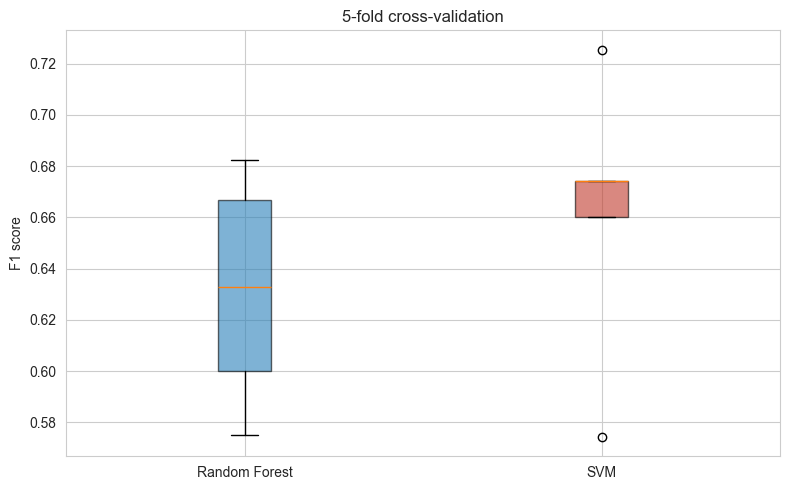

In [13]:
# نمایش پراکندگی امتیازهای اعتبارسنجی
plt.figure(figsize=(8, 5))
bp = plt.boxplot([rf_cv, svm_cv], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2980b9', '#c0392b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
plt.xticks([1, 2], ['Random Forest', 'SVM'])
plt.ylabel('F1 score')
plt.title('5-fold cross-validation')
plt.tight_layout()
plt.savefig('../figures/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## تنظیم هایپرپارامترها

با Grid Search و اعتبارسنجی ۵-تایی، بهترین تنظیمات هر دو مدل رو پیدا می‌کنم.

In [14]:
# جست‌وجوی بهترین پارامترهای Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]},
    cv=5, scoring='f1', n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print('RF best params:', rf_grid.best_params_)
print(f'RF best CV F1:  {rf_grid.best_score_:.3f}')

RF best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
RF best CV F1:  0.682


In [15]:
# جست‌وجوی بهترین پارامترهای SVM
svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
    cv=5, scoring='f1', n_jobs=-1,
)
svm_grid.fit(X_train, y_train)
print('SVM best params:', svm_grid.best_params_)
print(f'SVM best CV F1:  {svm_grid.best_score_:.3f}')

SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM best CV F1:  0.669


## انتخاب مدل نهایی

هر چهار حالت (پیش‌فرض و تنظیم‌شده هر دو مدل) رو توی یه جدول می‌ذارم و اونی که بهترین
F1 روی تست داره رو انتخاب می‌کنم.

چرا F1؟ چون داده نامتوازنه و کلاس دیابتی برام مهمه، نه فقط دقت کلی.

In [16]:
rf_tuned = rf_grid.best_estimator_
svm_tuned = svm_grid.best_estimator_

candidates = {
    'Random Forest (default)': rf,
    'Random Forest (tuned)': rf_tuned,
    'SVM (default)': svm,
    'SVM (tuned)': svm_tuned,
}

# معیارهای هر کاندید را در یک جدول جمع می‌کنم
rows = []
for name, model in candidates.items():
    m = evaluate(model)
    rows.append({'model': name, 'accuracy': m['accuracy'], 'precision': m['precision'],
                 'recall': m['recall'], 'f1': m['f1'], 'roc_auc': m['roc_auc']})

results = pd.DataFrame(rows).set_index('model').round(3)
results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest (default),0.747,0.660,0.574,0.614,0.811
Random Forest (tuned),0.740,0.625,0.648,0.636,0.821
SVM (default),0.727,0.591,0.722,0.650,0.814
SVM (tuned),0.669,0.519,0.778,0.622,0.787


In [17]:
# انتخاب بهترین مدل بر اساس F1 روی تست
best_name = results['f1'].idxmax()
best_model = candidates[best_name]

print('chosen model:', best_name)
print()
print(results.loc[best_name].to_string())
# نکته: تنظیم هایپرپارامتر امتیاز اعتبارسنجی را بهتر کرد ولی روی این تستِ کوچک
# (فقط ۱۵۴ سطر) همیشه برنده نیست کمی نوسان طبیعی است

chosen model: SVM (default)

accuracy     0.727
precision    0.591
recall       0.722
f1           0.650
roc_auc      0.814


## اهمیت ویژگی‌ها

ببینم Random Forest برای پیش‌بینی بیشتر روی کدوم ویژگی‌ها حساب می‌کنه.

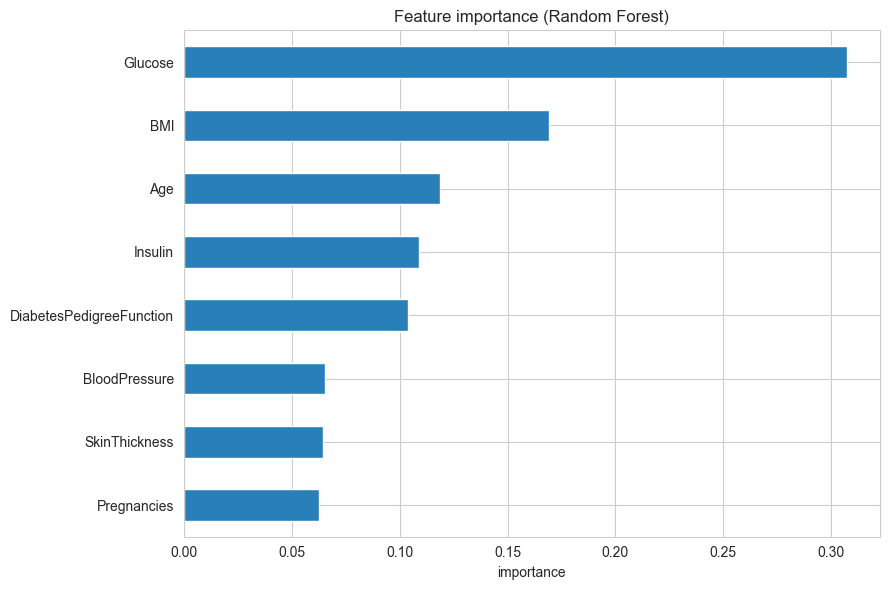

Glucose                     0.307
BMI                         0.169
Age                         0.119
Insulin                     0.109
DiabetesPedigreeFunction    0.104
BloodPressure               0.065
SkinThickness               0.064
Pregnancies                 0.063


In [18]:
# اهمیت ویژگی‌ها از روی Random Forest تنظیم‌شده
importance = pd.Series(rf_tuned.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='#2980b9')
plt.xlabel('importance')
plt.title('Feature importance (Random Forest)')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())

## ذخیرهٔ مدل‌ها

بهترین مدل و هر دو مدل تنظیم‌شده رو ذخیره می‌کنم.

In [19]:
os.makedirs('../models', exist_ok=True)

# ذخیرهٔ بهترین مدل و هر دو مدل تنظیم‌شده
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(rf_tuned, '../models/random_forest_model.pkl')
joblib.dump(svm_tuned, '../models/svm_model.pkl')
print('saved best_model.pkl  ->', best_name)
print('saved random_forest_model.pkl, svm_model.pkl')

saved best_model.pkl  -> SVM (default)
saved random_forest_model.pkl, svm_model.pkl


## خلاصه

In [20]:
print('Diabetes prediction - summary')
print('-' * 40)
print(f'samples:  {X_train.shape[0]} train / {X_test.shape[0]} test')
print(f'features: {X_train.shape[1]}')
print()
print('test-set F1 of each candidate:')
for name, model in candidates.items():
    print(f'  {name:26s} {evaluate(model)["f1"]:.3f}')
print()
print('chosen model:', best_name)
top3 = importance.sort_values(ascending=False).head(3)
print('top features:', ', '.join(top3.index))

Diabetes prediction - summary
----------------------------------------
samples:  614 train / 154 test
features: 8

test-set F1 of each candidate:
  Random Forest (default)    0.614
  Random Forest (tuned)      0.636
  SVM (default)              0.650
  SVM (tuned)                0.622

chosen model: SVM (default)
top features: Glucose, BMI, Age


## نتیجه‌گیری

هر دو مدل حدود ۷۵٪ دقت گرفتن و F1 نزدیک ۰.۶. مقدار ROC-AUC هم حدود ۰.۸۲ شد.

این تقریباً همون چیزیه که معمولاً روی این داده گزارش می‌شه، پس عملکرد رو متوسط می‌دونم
نه عالی. داده کوچیکه و کلاس دیابتی هم در اقلیته، برای همین کار سخته.

چند نکته:

- مهم‌ترین ویژگی گلوکز (Glucose) بود، بعد BMI و سن.
- مدل SVM فراخوانی (recall) بهتری داشت، یعنی دیابتی‌های بیشتری رو پیدا کرد.
- مدل Random Forest کمی دقیق‌تر بود (precision بالاتر).
- برای ابزار غربالگری، فراخوانی مهم‌تره؛ از دست دادن یه بیمار بدتر از هشدار اشتباهه.
- تنظیم هایپرپارامتر روی نتیجهٔ تست اثر کمی داشت، چون داده تست کوچیکه.



## آزمایش روی یک بیمار جدید

یه بررسی ساده: اطلاعات یه بیمار رو از همون مراحل آموزش رد می‌کنم (پر کردن صفر با
میانه‌های ذخیره‌شده و مقیاس‌بندی با scaler) و می‌بینم مدل چی می‌گه.

In [21]:
# اطلاعات یک بیمار نمونه
patient = {
    'Pregnancies': 2,
    'Glucose': 148,
    'BloodPressure': 72,
    'SkinThickness': 35,
    'Insulin': 0,
    'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627,
    'Age': 50,
}

# مدل و ابزارهای پیش‌پردازش ذخیره‌شده را می‌خوانم
model = joblib.load('../models/best_model.pkl')
prep = joblib.load('../models/preprocessed_data.pkl')
scaler = prep['scaler']
medians = prep['medians']

row = pd.DataFrame([patient])[prep['feature_names']]

# دقیقاً مثل آموزش: صفر را با میانه یادگرفته‌شده از train پر می‌کنم
for col, med in medians.items():
    row[col] = row[col].replace(0, med)

row_scaled = scaler.transform(row)
pred = model.predict(row_scaled)[0]
proba = model.predict_proba(row_scaled)[0]

print(f'P(no diabetes) = {proba[0]*100:.1f}%')
print(f'P(diabetes)    = {proba[1]*100:.1f}%')
print('prediction:', 'Diabetes' if pred == 1 else 'No diabetes')

P(no diabetes) = 20.4%
P(diabetes)    = 79.6%
prediction: Diabetes
